# 05 — Model Explainability with SHAP

## Objective

This notebook explains the predictions produced by the selected XGBoost
credit-risk model.

The objectives are to:

- identify the features that most influence model predictions globally
- understand whether features increase or decrease predicted default risk
- explain the prediction of an individual customer
- connect model predictions with financially meaningful risk drivers

SHAP (SHapley Additive exPlanations) is used to provide consistent
feature-attribution explanations for the tree-based model.

In [1]:
import pandas as pd
import numpy as np
import joblib
import json

from pathlib import Path
from sklearn.model_selection import train_test_split

import shap
import matplotlib.pyplot as plt

## 1. Load Saved Model

The trained XGBoost pipeline saved during the modeling stage is loaded
without retraining.

This ensures that SHAP explanations correspond to the exact model that
was selected and evaluated previously.

In [2]:
model_path = Path("../models/credit_risk_xgboost_pipeline.joblib")

model = joblib.load(model_path)

print("Model loaded successfully.")

Model loaded successfully.


## 2. Load Model Data

The feature-engineered dataset is loaded so that the model's
predictions can be connected back to the original customer features.

The target is separated from the predictors because SHAP explains the
model's prediction from the input features.

In [3]:
df = pd.read_csv(
    "../data/processed/credit_risk_features.csv"
)

X = df.drop(columns="default")
y = df["default"]

print("Dataset shape:", df.shape)
print("Feature shape:", X.shape)

Dataset shape: (29965, 34)
Feature shape: (29965, 33)


## 3. Inspect the Model Pipeline

The saved model is a scikit-learn Pipeline containing preprocessing
and XGBoost.

SHAP will explain the XGBoost estimator using the transformed feature
matrix produced by the preprocessing step.

In [4]:
print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['credit_limit', 'age',
                                                   'repayment_sep',
                                                   'repayment_aug',
                                                   'repayment_july',
                                                   'repayment_jun',
                                                   'repayment_may',
                                                   'repayment_apr', 'bill_sep',
                                                   'bill_aug', 'bill_july',
                                                   'bill_jun', 'bill_may',
                                                   'bill_apr', 'payment_sep',
                                                   'payment_aug',
                                                   'payment_july',
                                      

In [5]:
preprocessor = model.named_steps["preprocessor"]
xgb_model = model.named_steps["model"]

print("Preprocessor:", type(preprocessor).__name__)
print("Model:", type(xgb_model).__name__)

Preprocessor: ColumnTransformer
Model: XGBClassifier


## 4. Transform Features for SHAP

The XGBoost estimator does not receive the original DataFrame directly.
It receives the feature matrix generated by the preprocessing step.

We therefore transform the input data using the already-fitted
preprocessor from the saved pipeline.

In [6]:
X_transformed = preprocessor.transform(X)

print("Original shape:", X.shape)
print("Transformed shape:", X_transformed.shape)

Original shape: (29965, 33)
Transformed shape: (29965, 43)


## 5. Recover Model Feature Names

One-hot encoding expands categorical variables into multiple columns.
The transformed feature names are recovered so that SHAP explanations
remain interpretable.

In [7]:
feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(feature_names))
print(feature_names)

Number of transformed features: 43
['num__credit_limit' 'num__age' 'num__repayment_sep' 'num__repayment_aug'
 'num__repayment_july' 'num__repayment_jun' 'num__repayment_may'
 'num__repayment_apr' 'num__bill_sep' 'num__bill_aug' 'num__bill_july'
 'num__bill_jun' 'num__bill_may' 'num__bill_apr' 'num__payment_sep'
 'num__payment_aug' 'num__payment_july' 'num__payment_jun'
 'num__payment_may' 'num__payment_apr' 'num__num_delayed_months'
 'num__max_delay' 'num__avg_delay' 'num__recent_delay'
 'num__utilization_sep' 'num__avg_utilization' 'num__max_utilization'
 'num__total_payment_6m' 'num__recent_payment_3m' 'num__older_payment_3m'
 'cat__gender_1' 'cat__gender_2' 'cat__education_0' 'cat__education_1'
 'cat__education_2' 'cat__education_3' 'cat__education_4'
 'cat__education_5' 'cat__education_6' 'cat__marital_status_0'
 'cat__marital_status_1' 'cat__marital_status_2' 'cat__marital_status_3']


## 6. SHAP Analysis Sample

A representative sample of customers is used for the initial SHAP
analysis.

Using a sample reduces computation time while retaining enough
observations to identify the major global drivers of model predictions.

A fixed random state is used so that the analysis is reproducible.

In [8]:
sample_size = min(3000, len(X_transformed))

rng = np.random.default_rng(42)

sample_indices = rng.choice(
    len(X_transformed),
    size=sample_size,
    replace=False
)

X_shap = X_transformed[sample_indices]

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (3000, 43)


## 7. Create SHAP Tree Explainer

XGBoost is a tree-based model, so SHAP's TreeExplainer is appropriate
for explaining the model's feature contributions.

Each SHAP value represents the contribution of a feature to an
individual prediction relative to the model's baseline output.

In [9]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_shap)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (3000, 43)


## 8. Global Feature Importance

Global SHAP importance summarizes how strongly each transformed feature
influences model predictions across the SHAP sample.

Mean absolute SHAP value is used as the importance measure. A larger
value means the feature has a greater average impact on the model's
predictions, regardless of whether that impact increases or decreases
risk.

In [10]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

global_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

global_importance.head(20)

,feature,mean_abs_shap
22,num__avg_delay,0.263549
2,num__repayment_sep,0.237375
8,num__bill_sep,0.181383
20,num__num_delayed_months,0.166453
21,num__max_delay,0.102932
16,num__payment_july,0.102750
25,num__avg_utilization,0.099996
0,num__credit_limit,0.094778
23,num__recent_delay,0.087341
15,num__payment_aug,0.080119


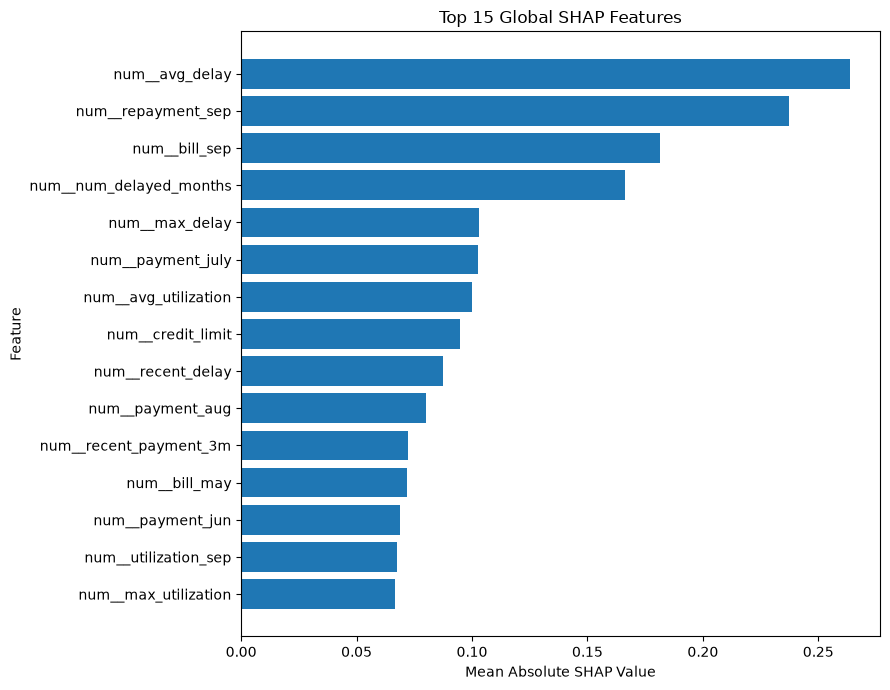

In [11]:
plt.figure(figsize=(9, 7))

top_features = global_importance.head(15).sort_values(
    "mean_abs_shap"
)

plt.barh(
    top_features["feature"],
    top_features["mean_abs_shap"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 15 Global SHAP Features")
plt.tight_layout()
plt.show()

### Interpretation

The global SHAP analysis shows that repayment behavior is the dominant
source of model influence.

`avg_delay` has the highest mean absolute SHAP value, followed by
`repayment_sep`, `bill_sep`, and `num_delayed_months`.

This indicates that the model places substantial importance on recent
and historical repayment behavior when distinguishing higher-risk
customers.

The presence of engineered features such as `avg_delay`,
`num_delayed_months`, and `avg_utilization` among the strongest
features also suggests that the feature-engineering stage captured
useful risk information.

Mean absolute SHAP measures the magnitude of influence, not whether a
feature increases or decreases risk.

## 9. Direction of Feature Impact

Global importance measures magnitude, but not direction.

The SHAP beeswarm plot shows how feature values are associated with
higher or lower model output.

Positive SHAP values indicate movement toward higher predicted default
risk, while negative values indicate movement toward lower predicted
risk.

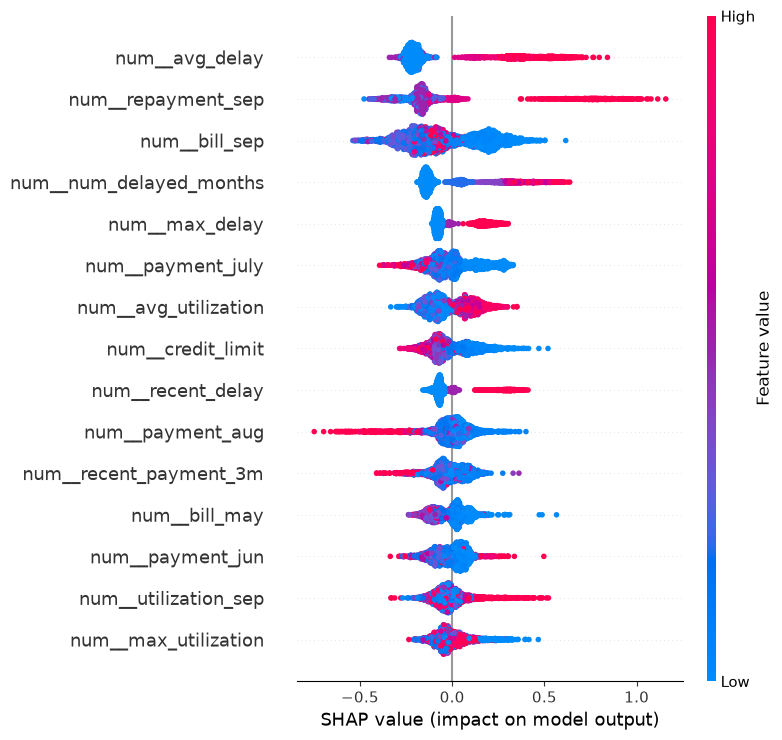

In [12]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    max_display=15,
    show=False
)

plt.tight_layout()
plt.show()

### How to Read the SHAP Beeswarm Plot

Each point represents one customer observation.

- Points to the right indicate a positive contribution to model output.
- Points to the left indicate a negative contribution.
- Color represents the feature value, with higher and lower values
  shown using different colors.

For example, high values of repayment-delay features generally appear
toward the positive side, indicating that larger delays tend to push
the model toward higher predicted default risk.

This describes model behavior, not causation.

### Global SHAP Interpretation

The SHAP analysis shows that repayment behavior is the strongest group
of predictors in the XGBoost model.

Average repayment delay has the highest mean absolute SHAP value,
followed by recent repayment status, bill amount, number of delayed
months, and maximum delay.

Several engineered features, including `avg_delay`,
`num_delayed_months`, `max_delay`, `recent_delay`, and
`avg_utilization`, appear among the most influential predictors. This
indicates that the feature-engineering stage captured meaningful
financial behavior information.

Higher repayment-delay values generally produce positive SHAP values,
moving the model toward higher predicted default risk.

SHAP values describe the model's contribution structure and should not
be interpreted as evidence of causal relationships.

In [13]:
categorical_prefixes = {
    "gender": "cat__gender_",
    "education": "cat__education_",
    "marital_status": "cat__marital_status_"
}

In [14]:
grouped_importance = global_importance.copy()

def map_to_original_feature(feature):
    if feature.startswith("num__"):
        return feature.replace("num__", "")
    
    for original, prefix in categorical_prefixes.items():
        if feature.startswith(prefix):
            return original
    
    return feature

grouped_importance["original_feature"] = (
    grouped_importance["feature"]
    .apply(map_to_original_feature)
)

In [15]:
original_importance = (
    grouped_importance
    .groupby("original_feature", as_index=False)["mean_abs_shap"]
    .sum()
    .sort_values("mean_abs_shap", ascending=False)
)

original_importance.head(20)

,original_feature,mean_abs_shap
1,avg_delay,0.263549
30,repayment_sep,0.237375
8,bill_sep,0.181383
15,num_delayed_months,0.166453
13,max_delay,0.102932
19,payment_july,0.102750
2,avg_utilization,0.099996
9,credit_limit,0.094778
23,recent_delay,0.087341
18,payment_aug,0.080119


### Original-Feature SHAP Interpretation

SHAP contributions from one-hot encoded categorical variables are
aggregated back to their original feature names to improve
interpretability.

At the original-feature level, repayment behavior is the dominant
source of model influence. `avg_delay`, `repayment_sep`,
`num_delayed_months`, `max_delay`, and `recent_delay` are among the
strongest predictors.

Financial variables such as `bill_sep`, `avg_utilization`,
`credit_limit`, and recent payment amounts also contribute materially
to the model output.

The results indicate that both repayment behavior and current credit
usage are important components of the model's risk assessment.

These SHAP importance values describe model behavior and should not be
interpreted as causal effects.

## 10. Recreate the Test Set

The individual explanation will use a customer from the same untouched
test set used during final model evaluation.

The original train/validation/test split is reproduced using the same
random state and stratification settings.

In [16]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

print("Test set shape:", X_test.shape)
print("Test target shape:", y_test.shape)

Test set shape: (5993, 33)
Test target shape: (5993,)


In [17]:
X_test_transformed = preprocessor.transform(X_test)

print("Transformed test shape:", X_test_transformed.shape)

Transformed test shape: (5993, 43)


In [18]:
xgb_test_proba = model.predict_proba(X_test)[:, 1]

print("Minimum PD:", xgb_test_proba.min())
print("Maximum PD:", xgb_test_proba.max())

Minimum PD: 0.0070680305
Maximum PD: 0.9236592


In [19]:
xgb_test_proba

array([0.10286799, 0.07756454, 0.15555465, ..., 0.20019147, 0.16669032,
       0.32911903], shape=(5993,), dtype=float32)

## 11. Individual Customer Explanation

Global SHAP analysis describes the model across the population.
Individual SHAP analysis explains why a specific customer's prediction
is high or low.

A high-risk test customer is selected as an example so that the
individual risk drivers can be examined.

In [20]:
high_risk_indices = np.where(
    xgb_test_proba >= 0.30
)[0]

example_position = high_risk_indices[
    np.argmax(xgb_test_proba[high_risk_indices])
]

example_pd = xgb_test_proba[example_position]

print("Example test position:", example_position)
print(f"Predicted PD: {example_pd:.2%}")

Example test position: 5775
Predicted PD: 92.37%


In [21]:
X_example = X_test_transformed[
    example_position:example_position + 1
]

In [22]:
example_shap_values = explainer.shap_values(
    X_example
)

example_shap_values = example_shap_values[0]

In [23]:
example_explanation = pd.DataFrame({
    "feature": feature_names,
    "feature_value": X_example[0],
    "shap_value": example_shap_values
})

example_explanation["abs_shap"] = (
    example_explanation["shap_value"].abs()
)

example_explanation = example_explanation.sort_values(
    "abs_shap",
    ascending=False
)

example_explanation.head(15)

,feature,feature_value,shap_value,abs_shap
2,num__repayment_sep,3.000000,0.695124,0.695124
22,num__avg_delay,4.666667,0.647041,0.647041
20,num__num_delayed_months,6.000000,0.348666,0.348666
23,num__recent_delay,3.000000,0.309368,0.309368
8,num__bill_sep,2400.000000,0.296111,0.296111
0,num__credit_limit,20000.000000,0.287358,0.287358
21,num__max_delay,7.000000,0.273676,0.273676
16,num__payment_july,0.000000,0.249071,0.249071
5,num__repayment_jun,7.000000,-0.169507,0.169507
7,num__repayment_apr,7.000000,0.155299,0.155299


### How to Interpret the Individual Explanation

The customer has a model-estimated PD of approximately 92.37%.

The largest positive SHAP contributions come from repayment-related
features. In particular, the customer experienced delays in all six
observed months, had an average delay of approximately 4.67, and had a
maximum delay of 7.

These factors collectively push the model toward a much higher-risk
prediction.

Negative SHAP values do not mean that a feature is universally
protective. They mean that, for this particular customer, the feature
moved the model output in the lower-risk direction.

In [24]:
risk_drivers = (
    example_explanation[
        example_explanation["shap_value"] > 0
    ]
    .head(10)
)

protective_factors = (
    example_explanation[
        example_explanation["shap_value"] < 0
    ]
    .sort_values("shap_value")
    .head(10)
)

## 12. Human-Readable Customer Explanation

The raw SHAP output uses the transformed feature space created by the
preprocessing pipeline.

For presentation and dashboard use, transformed one-hot categorical
features are grouped back into their original feature names.

For each original feature, we retain:

- the customer's original value
- the aggregated SHAP contribution
- the direction of the contribution

Positive SHAP contribution indicates movement toward higher model
output, while negative contribution indicates movement toward lower
model output.

In [25]:
example_customer = X_test.iloc[example_position]

print(example_customer)

credit_limit          20000.000000
gender                    2.000000
education                 2.000000
marital_status            1.000000
age                      32.000000
repayment_sep             3.000000
repayment_aug             2.000000
repayment_july            2.000000
repayment_jun             7.000000
repayment_may             7.000000
repayment_apr             7.000000
bill_sep               2400.000000
bill_aug               2400.000000
bill_july              2400.000000
bill_jun               2400.000000
bill_may               2400.000000
bill_apr               2400.000000
payment_sep               0.000000
payment_aug               0.000000
payment_july              0.000000
payment_jun               0.000000
payment_may               0.000000
payment_apr               0.000000
num_delayed_months        6.000000
max_delay                 7.000000
avg_delay                 4.666667
recent_delay              3.000000
utilization_sep           0.120000
avg_utilization     

In [26]:
def get_original_feature(feature_name):
    if feature_name.startswith("num__"):
        return feature_name.replace("num__", "")
    
    if feature_name.startswith("cat__gender_"):
        return "gender"
    
    if feature_name.startswith("cat__education_"):
        return "education"
    
    if feature_name.startswith("cat__marital_status_"):
        return "marital_status"
    
    return feature_name

In [27]:
example_explanation["original_feature"] = (
    example_explanation["feature"]
    .apply(get_original_feature)
)

In [28]:
human_explanation = (
    example_explanation
    .groupby("original_feature", as_index=False)
    .agg(
        shap_value=("shap_value", "sum"),
        abs_shap=("abs_shap", "sum")
    )
    .sort_values("abs_shap", ascending=False)
)

In [29]:
human_explanation["customer_value"] = (
    human_explanation["original_feature"]
    .map(example_customer.to_dict())
)

In [30]:
human_explanation["direction"] = np.where(
    human_explanation["shap_value"] > 0,
    "Higher risk",
    "Lower risk"
)

In [31]:
human_explanation.head(15)

,original_feature,shap_value,abs_shap,customer_value,direction
30,repayment_sep,0.695124,0.695124,3.000000,Higher risk
1,avg_delay,0.647041,0.647041,4.666667,Higher risk
15,num_delayed_months,0.348666,0.348666,6.000000,Higher risk
23,recent_delay,0.309368,0.309368,3.000000,Higher risk
8,bill_sep,0.296111,0.296111,2400.000000,Higher risk
9,credit_limit,0.287358,0.287358,20000.000000,Higher risk
13,max_delay,0.273676,0.273676,7.000000,Higher risk
19,payment_july,0.249071,0.249071,0.000000,Higher risk
28,repayment_jun,-0.169507,0.169507,7.000000,Lower risk
25,repayment_apr,0.155299,0.155299,7.000000,Higher risk


In [32]:
# Separate risk drivers and protective factors
top_risk_drivers = (
    human_explanation[
        human_explanation["shap_value"] > 0
    ]
    .sort_values("shap_value", ascending=False)
    .head(8)
)

top_protective_factors = (
    human_explanation[
        human_explanation["shap_value"] < 0
    ]
    .sort_values("shap_value")
    .head(8)
)

In [33]:
top_risk_drivers

,original_feature,shap_value,abs_shap,customer_value,direction
30,repayment_sep,0.695124,0.695124,3.000000,Higher risk
1,avg_delay,0.647041,0.647041,4.666667,Higher risk
15,num_delayed_months,0.348666,0.348666,6.000000,Higher risk
23,recent_delay,0.309368,0.309368,3.000000,Higher risk
8,bill_sep,0.296111,0.296111,2400.000000,Higher risk
9,credit_limit,0.287358,0.287358,20000.000000,Higher risk
13,max_delay,0.273676,0.273676,7.000000,Higher risk
19,payment_july,0.249071,0.249071,0.000000,Higher risk


In [34]:
top_protective_factors

,original_feature,shap_value,abs_shap,customer_value,direction
28,repayment_jun,-0.169507,0.169507,7.00,Lower risk
24,recent_payment_3m,-0.076878,0.076878,0.00,Lower risk
3,bill_apr,-0.058523,0.058523,2400.00,Lower risk
0,age,-0.025207,0.025207,32.00,Lower risk
11,gender,-0.011573,0.013180,2.00,Lower risk
2,avg_utilization,-0.006066,0.006066,0.12,Lower risk


### Individual Explanation Interpretation

The individual SHAP explanation identifies the features that most
strongly influenced the selected customer's predicted risk.

Positive contributions indicate that the feature moved the model output
toward higher default risk for this customer, while negative
contributions moved the output toward lower risk.

The explanation is specific to this customer. Feature effects are not
assumed to be causal and may differ for another customer because the
XGBoost model captures nonlinear relationships and interactions.

## 13. Human-Readable Feature Definitions

The source dataset contains coded categorical and repayment-status
variables. For customer-facing explanations, these codes are translated
into descriptive labels while the underlying model continues to use the
original encoded values.

In [35]:
repayment_labels = {
    -2: "No consumption",
    -1: "Paid duly",
     0: "Revolving credit",
     1: "1 month delay",
     2: "2 months delay",
     3: "3 months delay",
     4: "4 months delay",
     5: "5 months delay",
     6: "6 months delay",
     7: "7 months delay",
     8: "8 months delay",
     9: "9+ months delay"
}

gender_labels = {
    1: "Male",
    2: "Female"
}

education_labels = {
    0: "Unknown/other",
    1: "Graduate school",
    2: "University",
    3: "High school",
    4: "Other",
    5: "Other",
    6: "Other"
}

marital_labels = {
    0: "Unknown/other",
    1: "Married",
    2: "Single",
    3: "Other"
}

In [36]:
def readable_value(feature, value):
    if feature.startswith("repayment_"):
        return repayment_labels.get(int(value), str(value))

    if feature == "gender":
        return gender_labels.get(int(value), str(value))

    if feature == "education":
        return education_labels.get(int(value), str(value))

    if feature == "marital_status":
        return marital_labels.get(int(value), str(value))

    return value

In [37]:
human_explanation["readable_value"] = human_explanation.apply(
    lambda row: readable_value(
        row["original_feature"],
        row["customer_value"]
    ),
    axis=1
)

In [38]:
top_risk_drivers = (
    human_explanation[
        human_explanation["shap_value"] > 0
    ]
    .sort_values("shap_value", ascending=False)
    .head(8)
)

top_protective_factors = (
    human_explanation[
        human_explanation["shap_value"] < 0
    ]
    .sort_values("shap_value")
    .head(8)
)

In [39]:
top_risk_drivers[
    [
        "original_feature",
        "readable_value",
        "shap_value"
    ]
]

,original_feature,readable_value,shap_value
30,repayment_sep,3 months delay,0.695124
1,avg_delay,4.666667,0.647041
15,num_delayed_months,6.0,0.348666
23,recent_delay,3.0,0.309368
8,bill_sep,2400.0,0.296111
9,credit_limit,20000.0,0.287358
13,max_delay,7.0,0.273676
19,payment_july,0.0,0.249071


In [40]:
top_protective_factors[
    [
        "original_feature",
        "readable_value",
        "shap_value"
    ]
]

,original_feature,readable_value,shap_value
28,repayment_jun,7 months delay,-0.169507
24,recent_payment_3m,0.0,-0.076878
3,bill_apr,2400.0,-0.058523
0,age,32.0,-0.025207
11,gender,Female,-0.011573
2,avg_utilization,0.12,-0.006066


In [41]:
individual_explanation = {
    "pd": float(example_pd),
    "risk_tier": (
        "Low" if example_pd < 0.10
        else "Medium" if example_pd < 0.30
        else "High"
    ),
    "risk_drivers": top_risk_drivers[
        [
            "original_feature",
            "readable_value",
            "shap_value"
        ]
    ].to_dict("records"),
    "protective_factors": top_protective_factors[
        [
            "original_feature",
            "readable_value",
            "shap_value"
        ]
    ].to_dict("records")
}

In [42]:
individual_explanation

{'pd': 0.9236592054367065,
 'risk_tier': 'High',
 'risk_drivers': [{'original_feature': 'repayment_sep',
   'readable_value': '3 months delay',
   'shap_value': 0.6951243281364441},
  {'original_feature': 'avg_delay',
   'readable_value': 4.666666666666667,
   'shap_value': 0.6470414400100708},
  {'original_feature': 'num_delayed_months',
   'readable_value': 6.0,
   'shap_value': 0.34866631031036377},
  {'original_feature': 'recent_delay',
   'readable_value': 3.0,
   'shap_value': 0.30936750769615173},
  {'original_feature': 'bill_sep',
   'readable_value': 2400.0,
   'shap_value': 0.29611077904701233},
  {'original_feature': 'credit_limit',
   'readable_value': 20000.0,
   'shap_value': 0.2873583137989044},
  {'original_feature': 'max_delay',
   'readable_value': 7.0,
   'shap_value': 0.27367648482322693},
  {'original_feature': 'payment_july',
   'readable_value': 0.0,
   'shap_value': 0.2490713894367218}],
 'protective_factors': [{'original_feature': 'repayment_jun',
   'readable_

## 14. Explainability Summary

SHAP was used to explain both the global behavior of the XGBoost
credit-risk model and individual customer predictions.

Global SHAP analysis showed that repayment behavior is the strongest
group of predictors, with average delay, recent repayment status,
number of delayed months, and maximum delay among the most influential
features.

Individual SHAP analysis provides customer-specific explanations by
identifying features that push the prediction toward higher or lower
model output.

For the example high-risk customer, the dominant positive contributors
were severe and persistent repayment delays, including an average delay
of approximately 4.67 months, delays across all six observed months,
and a maximum delay of 7 months.

SHAP values explain the behavior of the trained model and should not be
interpreted as causal effects.